## EDA and Feature Engineering of Google Play Store Dataset

1. Problem Statement : Today, 1.85 million different apps are available for users to download. Android users have even more from which to choose. These apps have come to play a huge role in the way we live our lives today.
Our objective is to find the most popular category, find the app with largest number of installs, the app with largest size etc.
2. Data Collection.

The data consists of 20 column and 10841 rows


### Steps we are going to follow:-

1. Data Cleaning
2. Exploratory Data Analysis
3. Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.shape

(10841, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
## Missing values
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

## Insights and observation

The dataset has missing values

In [6]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


## Data Cleaning

In [7]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [8]:
## df['Reviews'].astype(int)

In [9]:

def convert_reviews(x):
    x = str(x).strip()

    if x.endswith("M"):
        return float(x[:-1]) * 1_00_000
    
    elif x.endswith("k") or x.endswith("K"):
        return float(x[:-1]) * 1_000
    
    elif x.isdigit():
        return int(x)
    
    else:
        return None
    


In [10]:
df_copy=df.copy()

In [11]:
df_copy['Reviews']=df['Reviews'].apply(convert_reviews)

In [12]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  float64
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), object(11)
memory usage: 1.1+ MB


In [13]:
# Convert Review Datatype to int
df_copy['Reviews']=df_copy['Reviews'].astype(int)

In [14]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [15]:
df_copy['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [16]:
## df_copy['Size'].astype(int)

In [17]:
df_copy['Size']=df_copy['Size'].apply(convert_reviews)

In [18]:
df_copy['Size'].astype(float)

0        1900000.0
1        1400000.0
2         870000.0
3        2500000.0
4         280000.0
           ...    
10836    5300000.0
10837     360000.0
10838     950000.0
10839          NaN
10840    1900000.0
Name: Size, Length: 10841, dtype: float64

In [19]:
df_copy['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [20]:
df_copy['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [21]:
char_to_remove=['$','+',',','Everyone','Free']
cols_to_clean=['Installs','Price']
for item in char_to_remove:
    for cols in cols_to_clean:
        df_copy[cols]=df_copy[cols].str.replace(item,'')

In [22]:
df_copy['Price'].unique()

array(['0', '4.99', '3.99', '6.99', '1.49', '2.99', '7.99', '5.99',
       '3.49', '1.99', '9.99', '7.49', '0.99', '9.00', '5.49', '10.00',
       '24.99', '11.99', '79.99', '16.99', '14.99', '1.00', '29.99',
       '12.99', '2.49', '10.99', '1.50', '19.99', '15.99', '33.99',
       '74.99', '39.99', '3.95', '4.49', '1.70', '8.99', '2.00', '3.88',
       '25.99', '399.99', '17.99', '400.00', '3.02', '1.76', '4.84',
       '4.77', '1.61', '2.50', '1.59', '6.49', '1.29', '5.00', '13.99',
       '299.99', '379.99', '37.99', '18.99', '389.99', '19.90', '8.49',
       '1.75', '14.00', '4.85', '46.99', '109.99', '154.99', '3.08',
       '2.59', '4.80', '1.96', '19.40', '3.90', '4.59', '15.46', '3.04',
       '4.29', '2.60', '3.28', '4.60', '28.99', '2.95', '2.90', '1.97',
       '200.00', '89.99', '2.56', '30.99', '3.61', '394.99', '1.26', '',
       '1.20', '1.04'], dtype=object)

In [23]:
df_copy['Installs'].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0', ''],
      dtype=object)

In [24]:
df_copy['Price']=df_copy['Price'].replace('',np.nan)
df_copy['Installs']=df_copy['Installs'].replace('',np.nan)

In [25]:
df_copy['Price']=df_copy['Price'].astype(float)

In [26]:
## Remove nan
df_copy['Price'] = df_copy['Price'].fillna(0)
df_copy['Installs'] = df_copy['Installs'].fillna(0)

In [27]:
df_copy['Installs']=df_copy['Installs'].astype(int)

In [28]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10841 non-null  int64  
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [29]:
df_copy['Installs'].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,         50,        100,
              500,         10,          1,          5,          0])

In [30]:
df_copy['Price'].unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [32]:
## Handling last updated feature
df_copy['Last Updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      shape=(1378,), dtype=object)

In [38]:
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'], errors='coerce')
df_copy['Day']=df_copy['Last Updated'].dt.day
df_copy['Month']=df_copy['Last Updated'].dt.month
df_copy['Year']=df_copy['Last Updated'].dt.year

In [39]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10841 non-null  object        
 1   Category        10841 non-null  object        
 2   Rating          9367 non-null   float64       
 3   Reviews         10841 non-null  int64         
 4   Size            9145 non-null   float64       
 5   Installs        10841 non-null  int64         
 6   Type            10840 non-null  object        
 7   Price           10841 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10841 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10833 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  float64       
 14  Month           10840 non-null  float64       
 15  Ye

In [42]:
df_copy['Last Updated'].unique()

<DatetimeArray>
['2018-01-07 00:00:00', '2018-01-15 00:00:00', '2018-08-01 00:00:00',
 '2018-06-08 00:00:00', '2018-06-20 00:00:00', '2017-03-26 00:00:00',
 '2018-04-26 00:00:00', '2018-06-14 00:00:00', '2017-09-20 00:00:00',
 '2018-07-03 00:00:00',
 ...
 '2015-11-23 00:00:00', '2012-06-17 00:00:00', '2015-02-27 00:00:00',
 '2013-12-18 00:00:00', '2012-02-06 00:00:00', '2014-11-25 00:00:00',
 '2016-05-19 00:00:00', '2014-01-20 00:00:00', '2014-02-16 00:00:00',
 '2014-03-23 00:00:00']
Length: 1378, dtype: datetime64[ns]

In [45]:
df_copy['Day'] = df_copy['Day'].fillna(0)
df_copy['Month'] = df_copy['Month'].fillna(0)
df_copy['Year'] = df_copy['Year'].fillna(0)

In [47]:
df_copy['Day']=df_copy['Day'].astype(int)
df_copy['Month']=df_copy['Month'].astype(int)
df_copy['Year']=df_copy['Year'].astype(int)

In [48]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1900000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,870000.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2500000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,280000.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [51]:
df_copy.to_csv('Csv File/google_cleaned.csv')

### EDA

In [53]:
df_copy[df_copy.duplicated('App')].shape

(1181, 16)

### Observation

The dataset has duplicated records.

In [54]:
df_copy=df_copy.drop_duplicates(subset=['App'],keep='first')

In [55]:
df_copy.shape

(9660, 16)

### Explore Data

In [62]:
numeric_features = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()
datetime_features = df_copy.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))
print("\nWe have {} datetime features : {}".format(len(datetime_features), datetime_features))

We have 8 numerical features : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month', 'Year']

We have 7 categorical features : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']

We have 1 datetime features : ['Last Updated']


## 3.2 Feature Information
1. App :- Name of the App
2. Category :- Category under which the App falls.
3. Rating :- Application's rating on playstore
4. Reviews :- Number of reviews of the App.
5. Size :- Size of the App.
6. Install :- Number of Installs of the App
7. Type :- If the App is free/paid
8. Price :- Price of the app (0 if it is Free)
9. Content Rating :- Appropiate Target Audience of the App.
10. Genres:- Genre under which the App falls.
11. Last Updated :- Date when the App was last updated
12. Current Ver :- Current Version of the Application
13. Android Ver :- Minimum Android Version required to run the App

In [64]:
## Proportion of count data on categorical columns
for col in categorical_features:
    print(df_copy[col].value_counts(normalize=True)*100)
    print('---------------------------------------------')

App
Photo Editor & Candy Camera & Grid & ScrapBook    0.010352
CK Pharmacies                                     0.010352
CK Call NEW                                       0.010352
Ck Coif                                           0.010352
CONTRACT KILLER: ZOMBIES                          0.010352
                                                    ...   
Bike Race Free - Top Motorcycle Racing Games      0.010352
Dance School Stories - Dance Dreams Come True     0.010352
3D Bowling                                        0.010352
Mind Games Pro                                    0.010352
iHoroscope - 2018 Daily Horoscope & Astrology     0.010352
Name: proportion, Length: 9660, dtype: float64
---------------------------------------------
Category
FAMILY                 18.964803
GAME                    9.927536
TOOLS                   8.561077
BUSINESS                4.347826
MEDICAL                 4.089027
PERSONALIZATION         3.892340
PRODUCTIVITY            3.871636
LIFESTYLE     

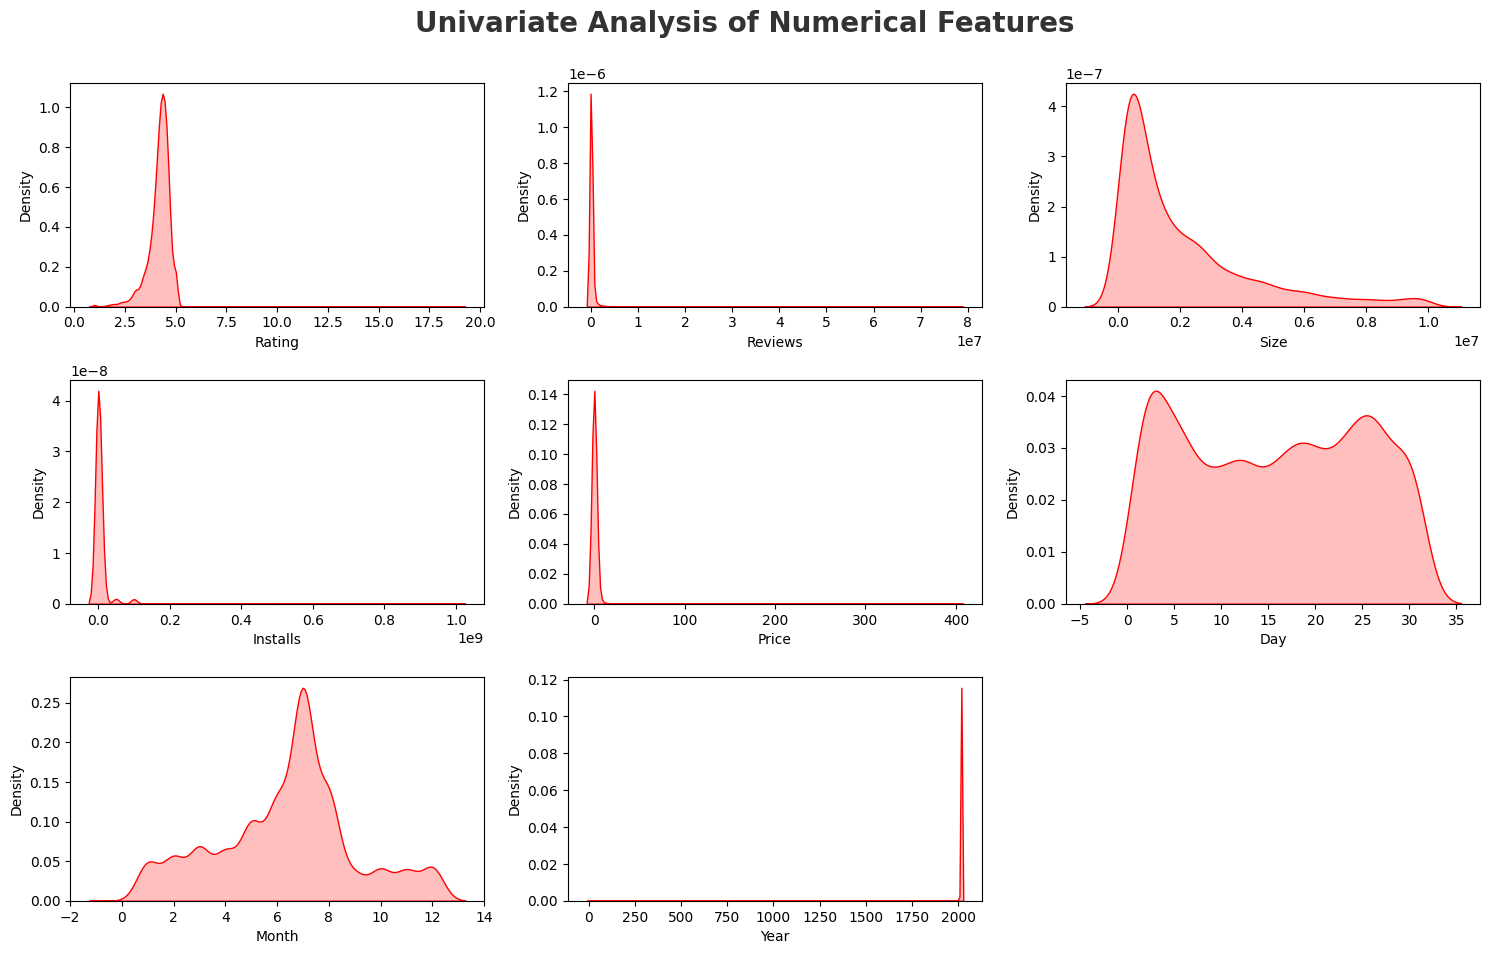

In [73]:
## Proportion of count data on numerical columns
plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]],shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout() ## Adjust spacing automatically.

## Observations
- Rating and Year is left skewed while Reviews,Size,Installs and Price are right skewed

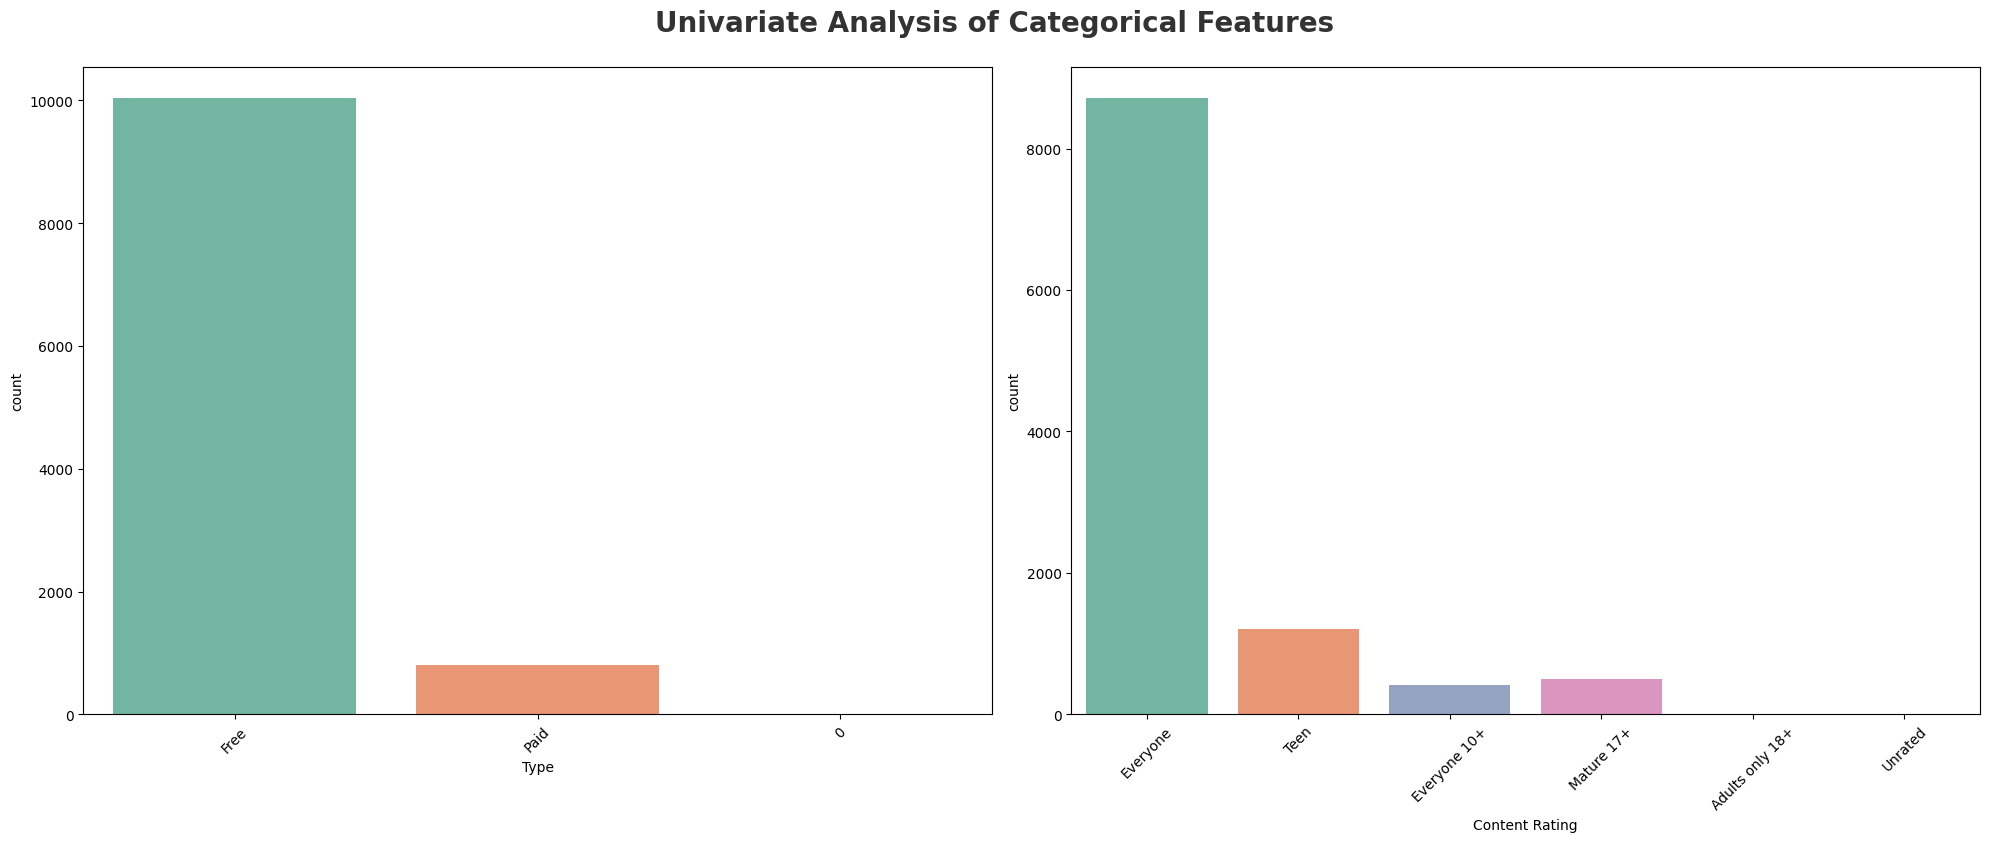

In [69]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = [ 'Type', 'Content Rating']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout() 

### Which is the most popular app category ?

<Axes: ylabel='count'>

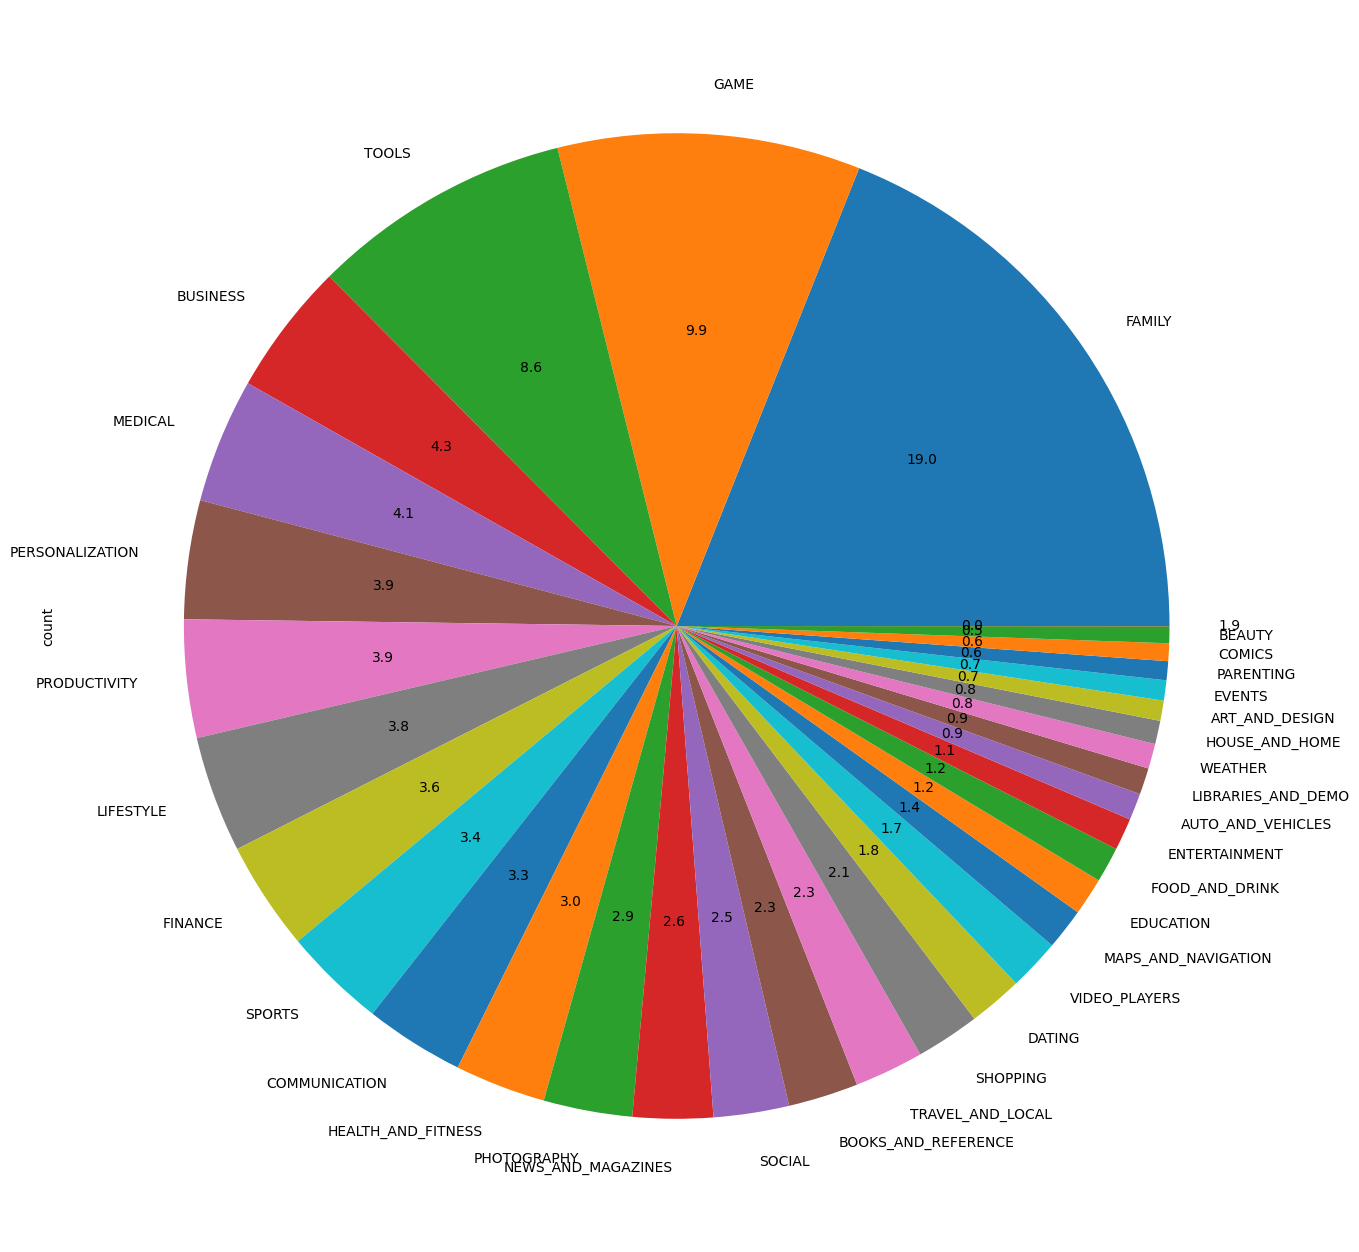

In [74]:
df_copy['Category'].value_counts().plot.pie(y=df_copy['Category'],figsize=(16,16),autopct='%1.1f')

In [101]:
category = pd.DataFrame(df_copy['Category'].value_counts())
category.columns = ['Count']
category.index.name = None

In [102]:
category

,Count
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345
SPORTS,325


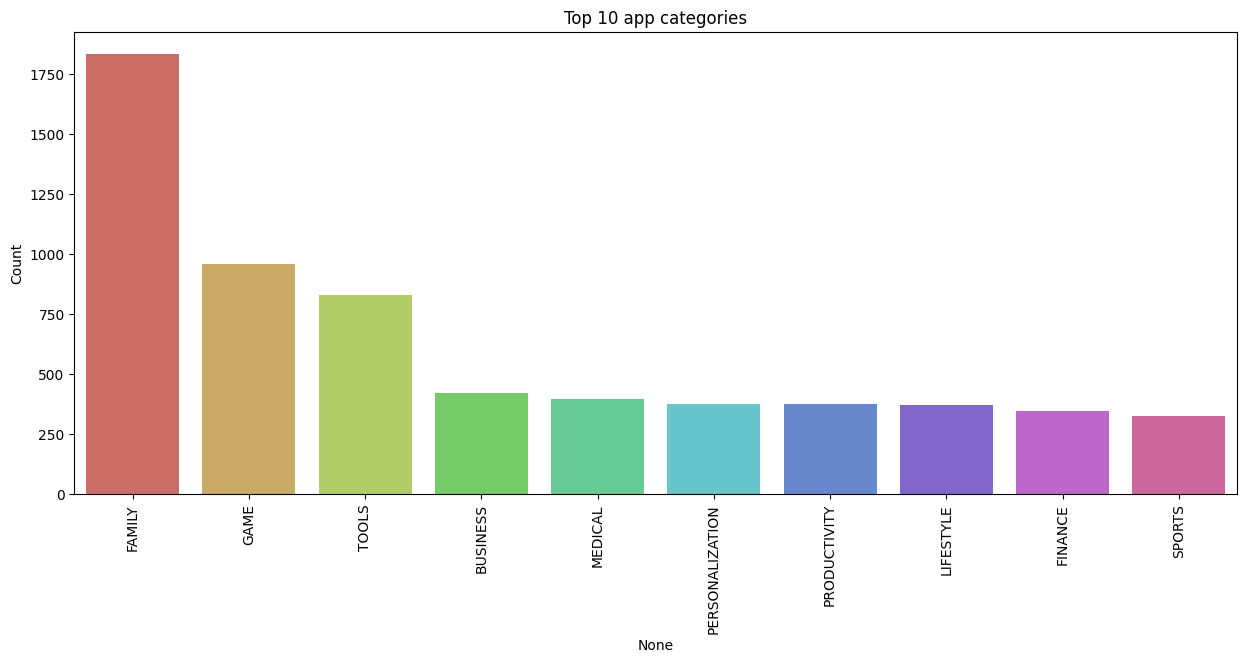

In [106]:
plt.figure(figsize=(15,6))
sns.barplot(x=category.index[:10],y='Count',data=category[:10],palette='hls')
plt.title('Top 10 app categories')
plt.xticks(rotation=90)
plt.show()

In [111]:
## group by
install_by_category=df_copy.groupby('Category')['Installs'].sum().reset_index()

In [112]:
install_by_category

,Category,Installs
0,1.9,0
1,ART_AND_DESIGN,114338100
2,AUTO_AND_VEHICLES,53130211
3,BEAUTY,27197050
4,BOOKS_AND_REFERENCE,1665969576
5,BUSINESS,697164865
6,COMICS,44981150
7,COMMUNICATION,11038276251
8,DATING,140926107
9,EDUCATION,352952000


In [190]:
## sort them.
install_by_category=install_by_category.sort_values(by='Installs',ascending=False)

In [123]:
install_by_category

,Category,Installs
15,GAME,13878924415
7,COMMUNICATION,11038276251
30,TOOLS,8001771915
26,PRODUCTIVITY,5793091369
28,SOCIAL,5487867902
25,PHOTOGRAPHY,4649147655
12,FAMILY,4427941505
32,VIDEO_PLAYERS,3926902720
31,TRAVEL_AND_LOCAL,2894887146
22,NEWS_AND_MAGAZINES,2369217760


In [125]:
install_by_category.iloc[0]

Category           GAME
Installs    13878924415
Name: 15, dtype: object

In [127]:
top_category = install_by_category.iloc[0]
print("Most Installed Category:", top_category['Category'])
print("Total Installs:", top_category['Installs'])


Most Installed Category: GAME
Total Installs: 13878924415


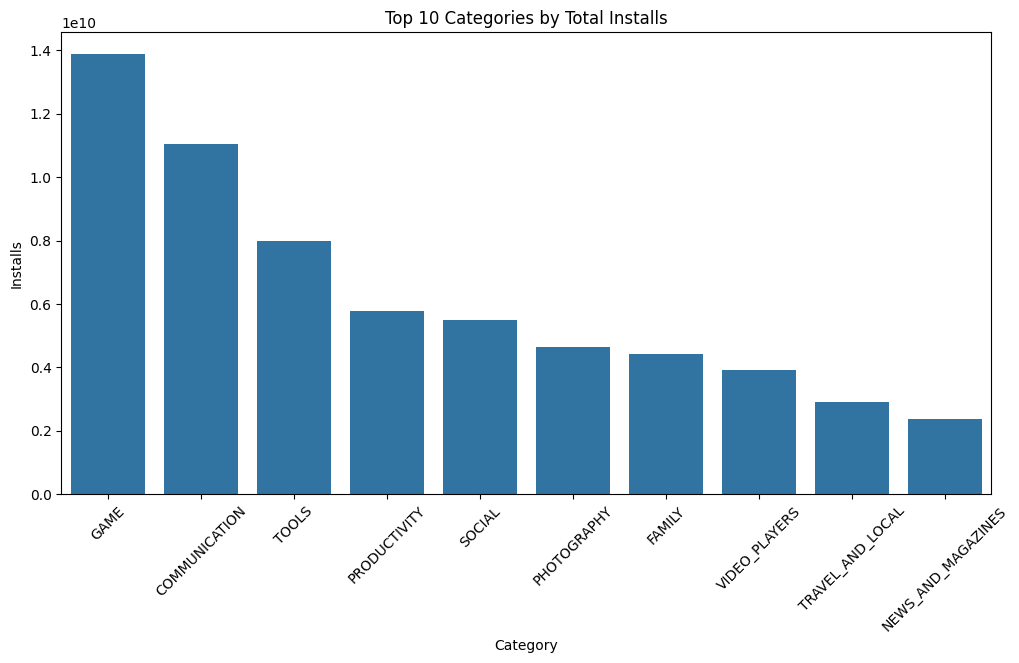

In [128]:
plt.figure(figsize=(12,6))
sns.barplot(data=install_by_category.head(10), x='Category', y='Installs')
plt.xticks(rotation=45)
plt.title("Top 10 Categories by Total Installs")
plt.show()


In [141]:
## What are the Top 5 most installed Apps in Each popular Categories ??

dfa = df_copy.groupby(['Category' ,'App'])['Installs'].sum().reset_index()

In [142]:
dfa

,Category,App,Installs
0,1.9,Life Made WI-Fi Touchscreen Photo Frame,0
1,ART_AND_DESIGN,350 Diy Room Decor Ideas,10000
2,ART_AND_DESIGN,3D Color Pixel by Number - Sandbox Art Coloring,100000
3,ART_AND_DESIGN,AJ Styles HD Wallpapers,5000
4,ART_AND_DESIGN,AJ Styles Wallpaper 2018 - AJ Styles HD Wallpaper,1000
...,...,...,...
9655,WEATHER,Yahoo Weather,10000000
9656,WEATHER,Yahoo! Weather for SH Forecast for understandi...,1000000
9657,WEATHER,Yandex.Weather,10000000
9658,WEATHER,weather - weather forecast,1000000


In [143]:
dfa=dfa.sort_values('Installs',ascending=False)

In [144]:
dfa

,Category,App,Installs
1535,ENTERTAINMENT,Google Play Games,1000000000
1056,COMMUNICATION,Gmail,1000000000
1065,COMMUNICATION,Hangouts,1000000000
7920,SOCIAL,Instagram,1000000000
9312,TRAVEL_AND_LOCAL,Google Street View,1000000000
...,...,...,...
7809,SOCIAL,Ak Parti Yardım Toplama,0
7964,SOCIAL,Pekalongan CJ,0
3663,FINANCE,Eu sou Rico,0
3662,FINANCE,Eu Sou Rico,0


In [157]:
## Select four popular categories
apps =['GAME','COMMUNICATION','TOOLS','PRODUCTIVITY','SOCIAL']

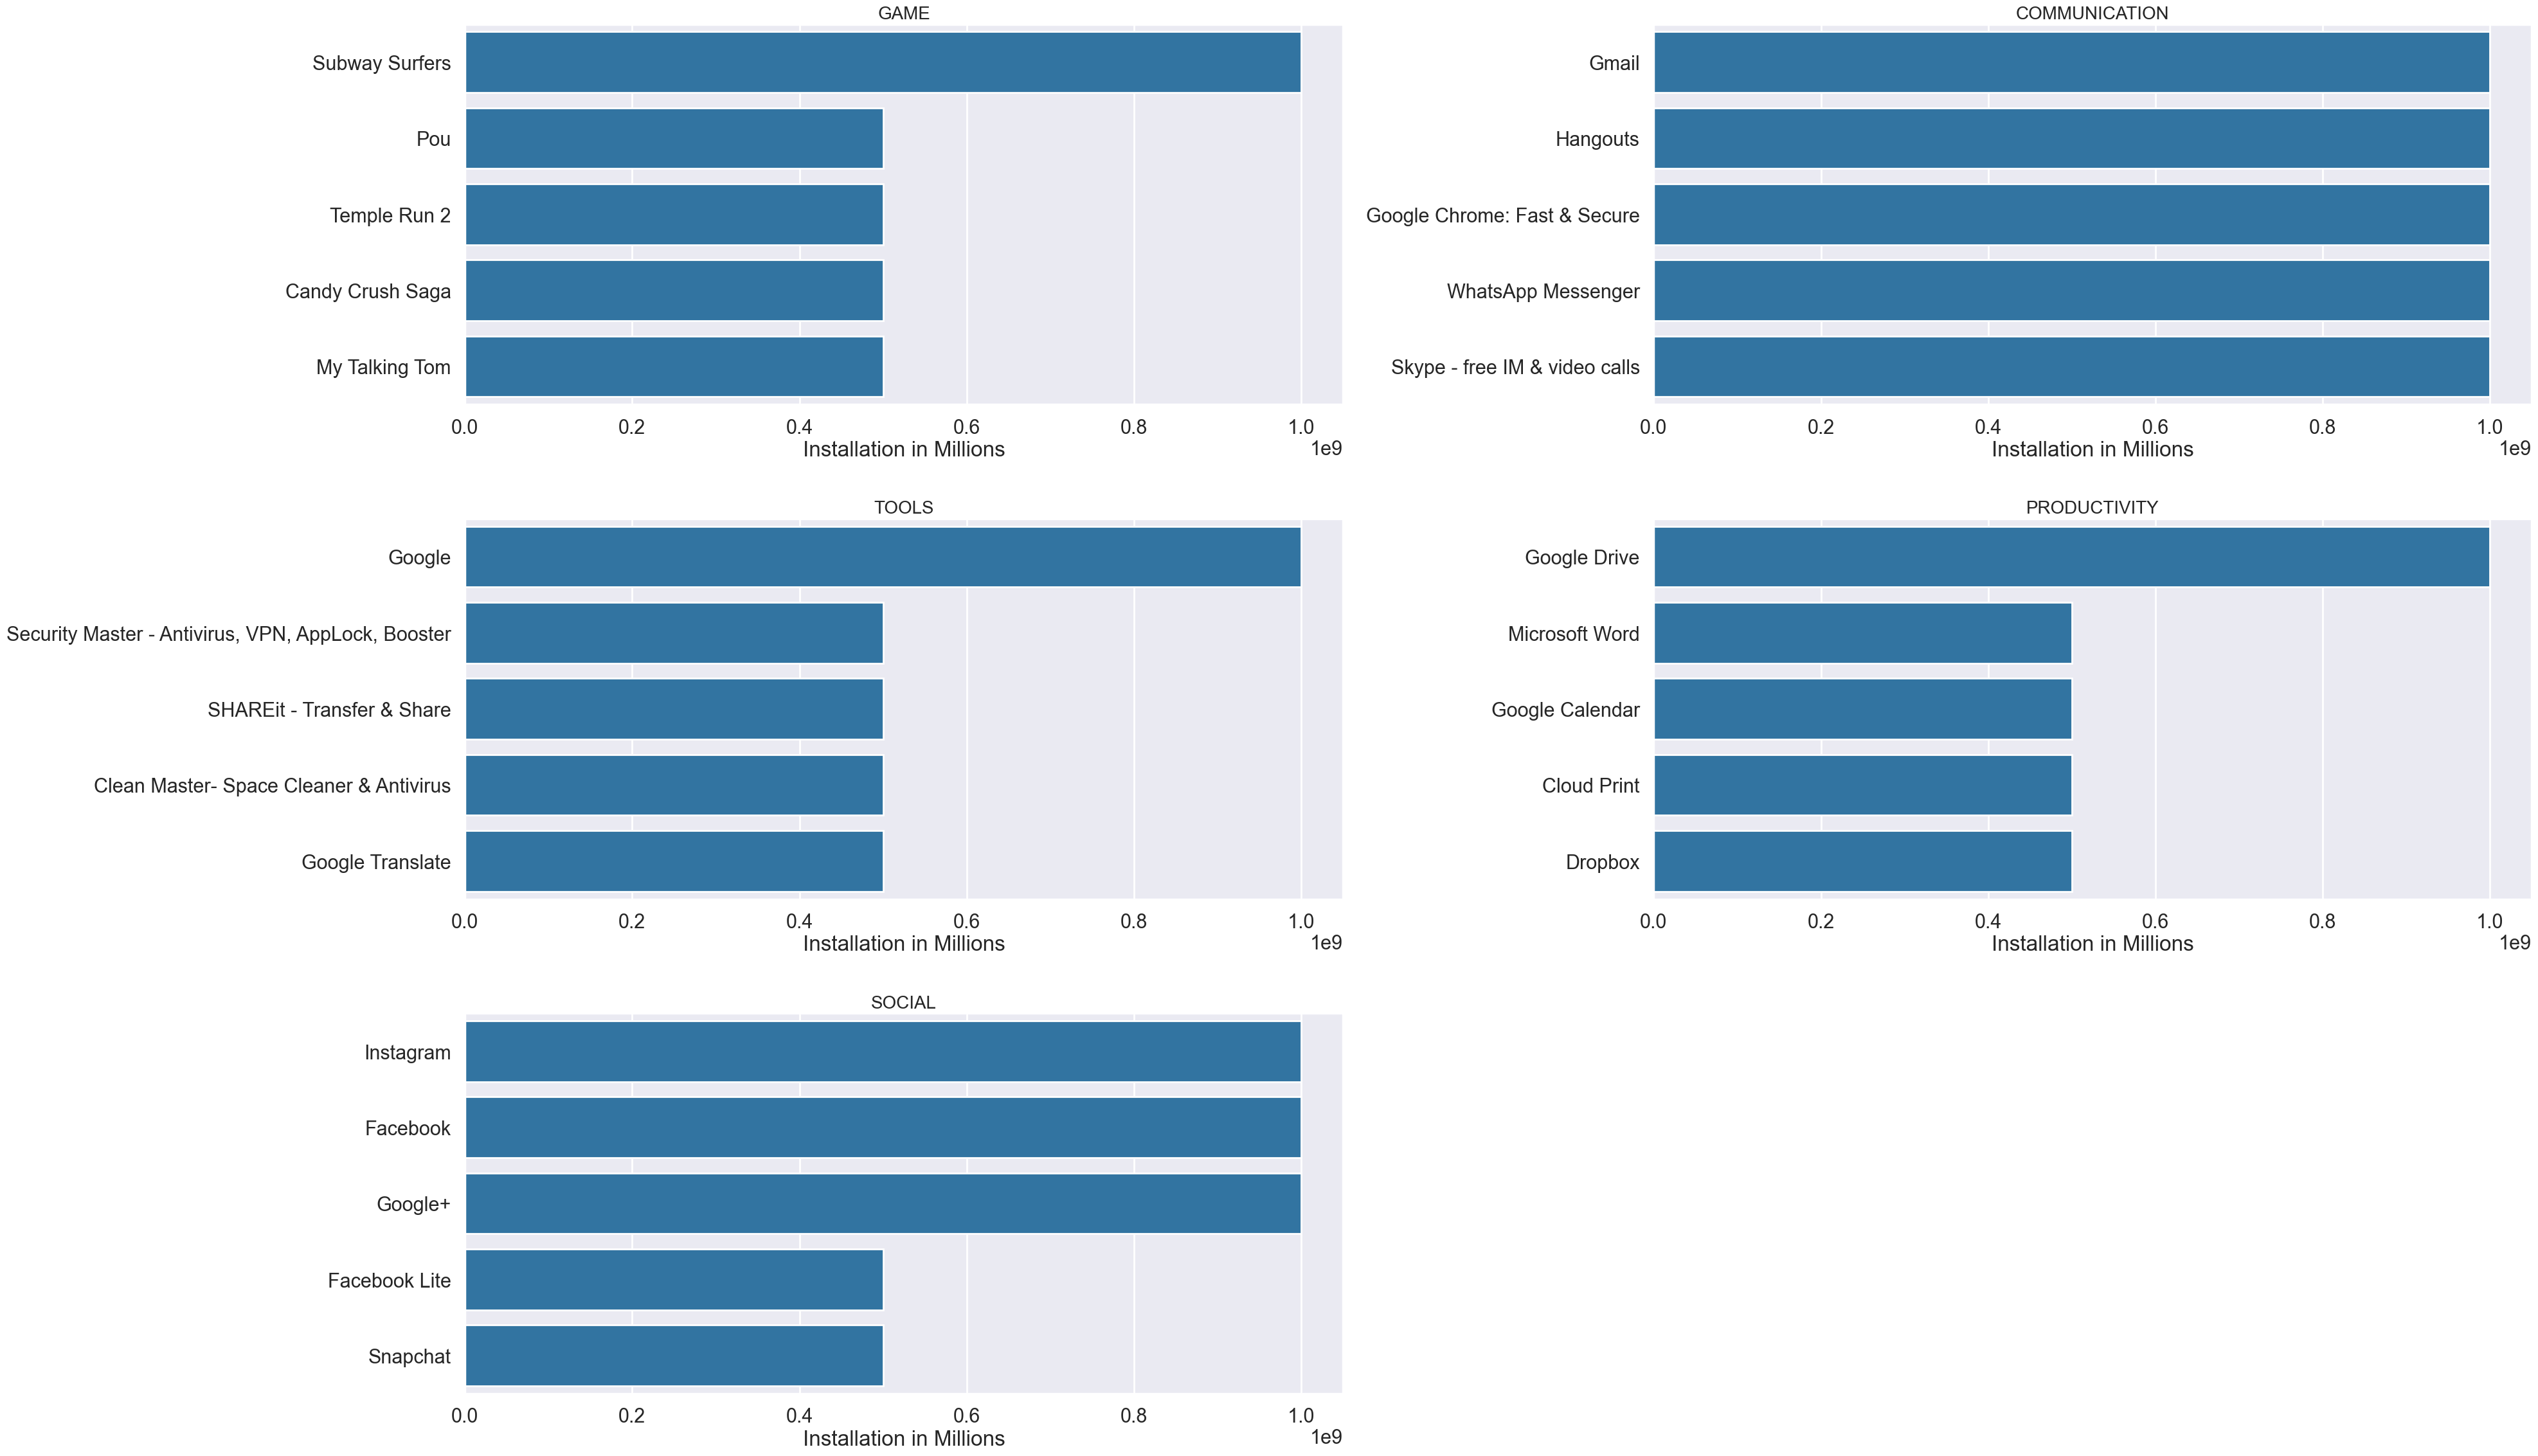

In [163]:
sns.set_context("poster")
sns.set_style('darkgrid')
plt.figure(figsize=(40,30))
for i,app in enumerate(apps):
    df2=dfa[dfa.Category == app]
    df3=df2.head(5)
    plt.subplot(4,2,i+1)
    sns.barplot(data=df3,x='Installs',y='App')
    plt.xlabel('Installation in Millions')
    plt.ylabel('')
    plt.title(app,size=20)
plt.tight_layout()
plt.subplots_adjust(hspace=.3)
plt.show()

In [ ]:
apps = ['GAME','COMMUNICATION','TOOLS','PRODUCTIVITY','SOCIAL']

for i, app in enumerate(apps):
    df2 = dfa[dfa.Category == app]
    df3 = df2.head(5)

    print("CATEGORY:", app)
    display(df3) ## When i use print then Output is truncated. View as a scrollable element or open in a text editor.
    ## 📌 This means → Jupyter has hidden the remaining rows to avoid flooding your screen.
    print("-" * 50)


CATEGORY: GAME


,Category,App,Installs
4774,GAME,Subway Surfers,1000000000
4629,GAME,Pou,500000000
4803,GAME,Temple Run 2,500000000
4168,GAME,Candy Crush Saga,500000000
4581,GAME,My Talking Tom,500000000


--------------------------------------------------
CATEGORY: COMMUNICATION


,Category,App,Installs
1056,COMMUNICATION,Gmail,1000000000
1065,COMMUNICATION,Hangouts,1000000000
1059,COMMUNICATION,Google Chrome: Fast & Secure,1000000000
1182,COMMUNICATION,WhatsApp Messenger,1000000000
1146,COMMUNICATION,Skype - free IM & video calls,1000000000


--------------------------------------------------
CATEGORY: TOOLS


...

--------------------------------------------------
CATEGORY: PRODUCTIVITY


,Category,App,Installs
7428,PRODUCTIVITY,Google Drive,1000000000
7473,PRODUCTIVITY,Microsoft Word,500000000
7426,PRODUCTIVITY,Google Calendar,500000000
7335,PRODUCTIVITY,Cloud Print,500000000
7365,PRODUCTIVITY,Dropbox,500000000


--------------------------------------------------
CATEGORY: SOCIAL


,Category,App,Installs
7920,SOCIAL,Instagram,1000000000
7884,SOCIAL,Facebook,1000000000
7909,SOCIAL,Google+,1000000000
7886,SOCIAL,Facebook Lite,500000000
7985,SOCIAL,Snapchat,500000000


--------------------------------------------------


How many apps are there on Google Play Store which get 5 ratings??

In [191]:
rating=df_copy.groupby(['Category','Installs','App'])['Rating'].sum().reset_index()

In [192]:
rating

,Category,Installs,App,Rating
0,1.9,0,Life Made WI-Fi Touchscreen Photo Frame,19.0
1,ART_AND_DESIGN,0,Test Application DT 02,0.0
2,ART_AND_DESIGN,100,Spring flowers theme couleurs d t space,5.0
3,ART_AND_DESIGN,1000,AJ Styles Wallpaper 2018 - AJ Styles HD Wallpaper,4.0
4,ART_AND_DESIGN,1000,X Launcher Prime: With OS Style Theme & No Ads,4.7
...,...,...,...,...
9655,WEATHER,10000000,wetter.com - Weather and Radar,4.2
9656,WEATHER,50000000,AccuWeather: Daily Forecast & Live Weather Rep...,4.4
9657,WEATHER,50000000,"GO Weather - Widget, Theme, Wallpaper, Efficient",4.5
9658,WEATHER,50000000,The Weather Channel: Rain Forecast & Storm Alerts,4.4


In [195]:
rating=rating.sort_values(by='Rating',ascending=False)

In [196]:
rating

,Category,Installs,App,Rating
0,1.9,0,Life Made WI-Fi Touchscreen Photo Frame,19.0
1852,FAMILY,100,EC Calgary,5.0
1864,FAMILY,100,Foothills CP,5.0
1865,FAMILY,100,Fr. Mike Schmitz Audio Teachings,5.0
1867,FAMILY,100,HON. B.J. ACS COLLEGE ALE,5.0
...,...,...,...,...
6612,PERSONALIZATION,50,HD Themes Toyota Cruiser 50,0.0
6613,PERSONALIZATION,50,SLANGY-Perfect BK World Theme,0.0
6615,PERSONALIZATION,50,iLauncher OS 12 Pro - Phone X,0.0
8455,TOOLS,100,DM AirDisk HDD,0.0


In [197]:
toprating_apps=rating[rating.Rating == 5.0]

In [199]:
display(toprating_apps)

,Category,Installs,App,Rating
1852,FAMILY,100,EC Calgary,5.0
1864,FAMILY,100,Foothills CP,5.0
1865,FAMILY,100,Fr. Mike Schmitz Audio Teachings,5.0
1867,FAMILY,100,HON. B.J. ACS COLLEGE ALE,5.0
1877,FAMILY,100,Morse Player,5.0
...,...,...,...,...
9221,TRAVEL_AND_LOCAL,100,Florida Beach Wallpapers HD,5.0
9224,TRAVEL_AND_LOCAL,500,CJ's Coffee Cafe,5.0
238,BOOKS_AND_REFERENCE,100,Hey AJ! It's Saturday!,5.0
2391,FAMILY,10000,Ek Bander Ne Kholi Dukan,5.0


In [201]:
print("Number of 5 rated apps",toprating_apps.shape[0])

Number of 5 rated apps 271


In [204]:
toprating_apps.head(1)

,Category,Installs,App,Rating
1852,FAMILY,100,EC Calgary,5.0


### Result
- There are 271 five rated apps on google play store
- Top most is EC Calgary from Family category

In [205]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1900000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,870000.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2500000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,280000.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018
